# Heart Disease Detection — Linear Model: Logistic Regression (CRISP-DM Stage 2)

This notebook implements a **Linear model** using **Logistic Regression** as a candidate champion model for heart disease prediction.

## Stage 2 Objectives
- Encode the target variable and analyse class imbalance
- Build a scikit-learn **Pipeline** (StandardScaler + LogisticRegression) to prevent data leakage
- Tune hyperparameters with **RandomizedSearchCV** (50 iterations, 5-fold CV)
- Output **probability scores** (0.0–1.0) and apply a custom **decision threshold**
- Evaluate with Classification Report, Confusion Matrix, ROC-AUC
- Perform **failure analysis** (top 10 most confident failures)
- Interpret model coefficients for feature importance
- Produce comparison metrics for group integration


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")
print(f"Random State: {RANDOM_STATE}")


Libraries imported successfully!
Random State: 42


## 2. Load Data from Data Preparation Stage


In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")

print("\nPreview of X_train:")
display(X_train.head())


X_train shape: (352827, 76)
X_test  shape: (88414, 76)
y_train shape: (352827,)
y_test  shape: (88414,)

Preview of X_train:


,Sex,PhysicalHealthDays,MentalHealthDays,PhysicalActivities,SleepHours,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,...,AgeCategory_Age 70 to 74,AgeCategory_Age 75 to 79,AgeCategory_Age 80 or older,"TetanusLast10Tdap_No, did not receive any tetanus shot in the past 10 years","TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",CovidPos_No,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
0,0,15.0,30.0,1,4.0,0,0,0,1,1,...,False,False,False,True,False,False,False,True,False,False
1,1,0.0,3.0,0,7.0,0,0,0,0,1,...,False,False,False,False,False,True,False,True,False,False
2,0,30.0,0.0,0,7.0,0,0,1,1,0,...,False,True,False,False,False,False,True,True,False,False
3,1,0.0,0.0,1,8.0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,False
4,0,5.0,0.0,0,8.0,0,0,1,0,0,...,False,True,False,True,False,False,False,True,False,False


## 3. Encode Target Variable & Check Class Imbalance

The target variable is expected to contain:
- `"No"` for the negative class
- `"Yes"` for the positive class

We encode the labels into:
- `0 = No`
- `1 = Yes`

Because the dataset is strongly imbalanced, this section also inspects the class ratio before modelling.
This is important because a high raw accuracy may still hide poor detection of actual heart attack cases.


In [3]:
# Encode target: "Yes" -> 1, "No" -> 0
le = LabelEncoder()
le.fit(["No", "Yes"])
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nTraining set target distribution:")
unique, counts = np.unique(y_train_enc, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]} ({label}): {count} ({count/len(y_train_enc)*100:.2f}%)")

neg_count = np.sum(y_train_enc == 0)
pos_count = np.sum(y_train_enc == 1)
imbalance_ratio = neg_count / pos_count

print(f"\nClass imbalance ratio (No:Yes): {imbalance_ratio:.2f}:1")
print("\nStage 2 handling strategy:")
print("  1. StandardScaler for linear model stability")
print("  2. Tune class_weight to penalize false negatives more heavily")
print("  3. Tune decision threshold after probability prediction")


Label mapping: {np.str_('No'): np.int64(0), np.str_('Yes'): np.int64(1)}

Training set target distribution:
  No (0): 332781 (94.32%)
  Yes (1): 20046 (5.68%)

Class imbalance ratio (No:Yes): 16.60:1

Stage 2 handling strategy:
  1. StandardScaler for linear model stability
  2. Tune class_weight to penalize false negatives more heavily
  3. Tune decision threshold after probability prediction


## 4. Build Scikit-learn Pipeline

The pipeline bundles a `StandardScaler` and the `LogisticRegression` estimator together to keep the workflow clean and reproducible.

Even though the prepared dataset has already been encoded and cleaned, scaling is still useful here because Logistic Regression optimization tends to behave more consistently when feature magnitudes are normalized.


In [4]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    )),
])

print("Pipeline created:")
print(pipeline)


Pipeline created:
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=5000, random_state=42))])


## 5. Hyperparameter Tuning with RandomizedSearchCV

We tune the main Logistic Regression hyperparameters over **50 iterations** with **5-fold stratified cross-validation**.

The search space includes:
- `C` for regularization strength,
- `class_weight` to handle imbalance and reduce costly false negatives,
- `solver`,
- `penalty`.

The primary optimization metric is **F1-score** for the positive class (`"Yes"`), because Stage 2 aims to improve minority-class detection while keeping precision at a usable level.


In [5]:
param_distributions = {
    "logreg__C": np.logspace(-3, 2, 20),
    "logreg__class_weight": [
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
        {0: 1, 1: 6},
        {0: 1, 1: 8},
        {0: 1, 1: 10},
    ],
    "logreg__solver": ["liblinear", "saga"],
    "logreg__penalty": ["l1", "l2"],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("Starting RandomizedSearchCV (50 iterations, 5-fold CV)...")
random_search.fit(X_train, y_train_enc)
print("\nSearch complete!")


Starting RandomizedSearchCV (50 iterations, 5-fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\donov\Desktop\SIT\2026\INF2008\HeartDiseaseDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\donov\Desktop\SIT\2026\INF2008\HeartDiseaseDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Search complete!


In [6]:
print("Best hyperparameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1-score: {random_search.best_score_:.4f}")

best_pipeline = random_search.best_estimator_


Best hyperparameters found:
  logreg__solver: liblinear
  logreg__penalty: l1
  logreg__class_weight: {0: 1, 1: 5}
  logreg__C: 0.02069138081114789

Best CV F1-score: 0.3250


## 6. Probability Output & Custom Decision Threshold

Instead of relying only on the default threshold of `0.50`, we first inspect the output probabilities produced by the tuned model.

This is important because, in a medical triage setting, the default threshold may not reflect the desired trade-off between:
- catching more high-risk patients (**higher recall**),
- and limiting the number of false alarms (**higher precision**).


In [7]:
# Predict probabilities on the test set
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print("Probability score summary (P(HeartAttack=Yes)):")
print(f"  Min:    {y_proba.min():.4f}")
print(f"  Max:    {y_proba.max():.4f}")
print(f"  Mean:   {y_proba.mean():.4f}")
print(f"  Median: {np.median(y_proba):.4f}")

# Default threshold
y_pred_default = (y_proba >= 0.5).astype(int)

print(f"\nPredictions with default threshold (0.50):")
print(f"  Predicted Yes: {np.sum(y_pred_default == 1)}")
print(f"  Predicted No:  {np.sum(y_pred_default == 0)}")


Probability score summary (P(HeartAttack=Yes)):
  Min:    0.0032
  Max:    0.9821
  Mean:   0.1815
  Median: 0.1067

Predictions with default threshold (0.50):
  Predicted Yes: 7866
  Predicted No:  80548


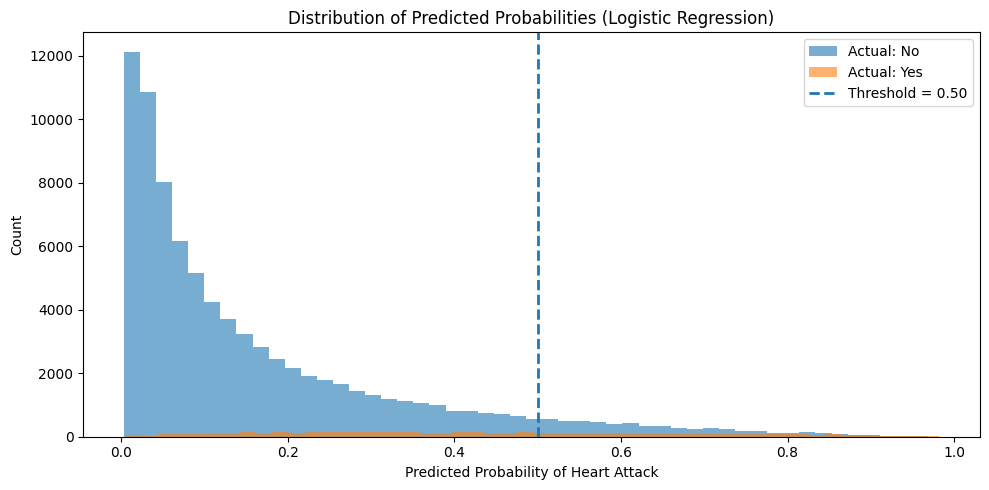

In [8]:
# Visualise the probability distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_proba[y_test_enc == 0], bins=50, alpha=0.6, label="Actual: No")
ax.hist(y_proba[y_test_enc == 1], bins=50, alpha=0.6, label="Actual: Yes")
ax.axvline(0.5, linestyle="--", linewidth=2, label="Threshold = 0.50")
ax.set_xlabel("Predicted Probability of Heart Attack")
ax.set_ylabel("Count")
ax.set_title("Distribution of Predicted Probabilities (Logistic Regression)")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Threshold Optimization

Threshold tuning is one of the main Stage 2 improvements.

Here, we sweep thresholds from `0.10` to `0.90` and compare:
- **F1-score**
- **Precision**
- **Recall**
- **Accuracy**

The threshold with the highest F1-score is selected as the default operating point for this notebook.


In [9]:
# Sweep thresholds from 0.10 to 0.90 in steps of 0.05
thresholds_sweep = np.arange(0.10, 0.91, 0.05)

results = []
for t in thresholds_sweep:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test_enc, y_pred_t, zero_division=0)
    prec = precision_score(y_test_enc, y_pred_t, zero_division=0)
    rec = recall_score(y_test_enc, y_pred_t, zero_division=0)
    acc = accuracy_score(y_test_enc, y_pred_t)
    results.append({
        "Threshold": round(t, 2),
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Accuracy": acc
    })

threshold_df = pd.DataFrame(results)

print("Threshold Search Results")
print("=" * 60)
print(threshold_df.to_string(index=False, float_format="{:.4f}".format))


Threshold Search Results
 Threshold     F1  Precision  Recall  Accuracy
    0.1000 0.1865     0.1035  0.9431    0.5327
    0.1500 0.2177     0.1242  0.8791    0.6411
    0.2000 0.2454     0.1445  0.8142    0.7156
    0.2500 0.2689     0.1639  0.7475    0.7691
    0.3000 0.2864     0.1820  0.6716    0.8099
    0.3500 0.2994     0.1994  0.6002    0.8405
    0.4000 0.3115     0.2198  0.5344    0.8658
    0.4500 0.3162     0.2388  0.4677    0.8851
    0.5000 0.3166     0.2593  0.4062    0.9004
    0.5500 0.3089     0.2798  0.3447    0.9124
    0.6000 0.2951     0.3029  0.2877    0.9219
    0.6500 0.2738     0.3339  0.2320    0.9301
    0.7000 0.2366     0.3541  0.1776    0.9349
    0.7500 0.1979     0.3987  0.1316    0.9394
    0.8000 0.1453     0.4308  0.0874    0.9416
    0.8500 0.0896     0.4816  0.0494    0.9430
    0.9000 0.0351     0.5353  0.0181    0.9433


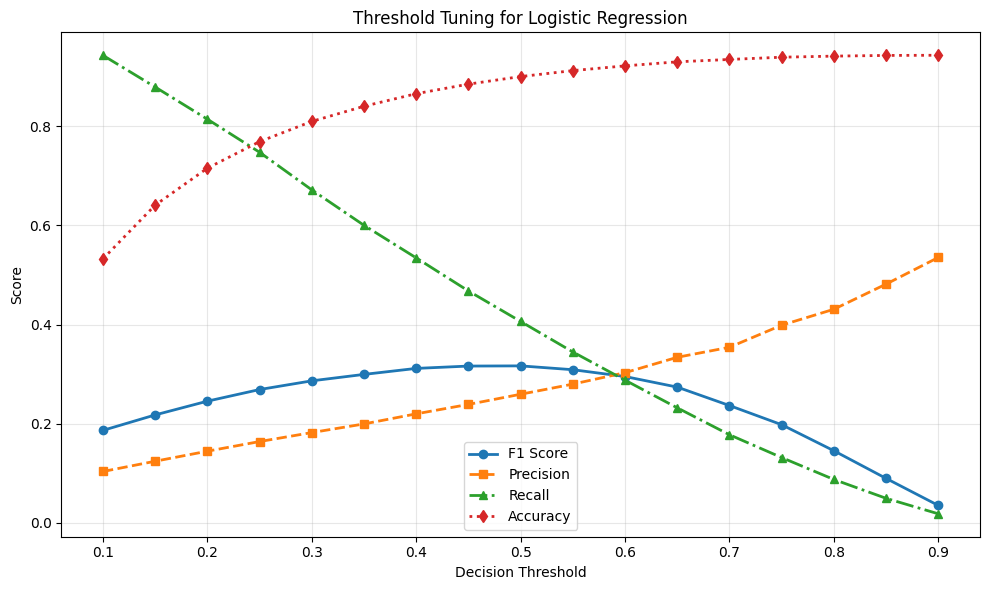

In [10]:
# Plot F1, Precision, Recall, Accuracy vs Threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", linewidth=2, label="F1 Score")
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="s", linestyle="--", linewidth=2, label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="^", linestyle="-.", linewidth=2, label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["Accuracy"], marker="d", linestyle=":", linewidth=2, label="Accuracy")

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning for Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# Apply optimal threshold based on highest F1
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
OPTIMAL_THRESHOLD = best_row["Threshold"]

print(f"Optimal threshold based on highest F1-score: {OPTIMAL_THRESHOLD:.2f}")
print("\nScores at optimal threshold:")
print(best_row)

y_pred_optimal = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

print(f"\nPredictions with optimal threshold ({OPTIMAL_THRESHOLD:.2f}):")
print(f"  Predicted Yes: {np.sum(y_pred_optimal == 1)}")
print(f"  Predicted No:  {np.sum(y_pred_optimal == 0)}")


Optimal threshold based on highest F1-score: 0.50

Scores at optimal threshold:
Threshold    0.500000
F1           0.316574
Precision    0.259344
Recall       0.406213
Accuracy     0.900378
Name: 8, dtype: float64

Predictions with optimal threshold (0.50):
  Predicted Yes: 7866
  Predicted No:  80548


## 8. Evaluation & Failure Analysis


### 8.1 Classification Report (Optimal Threshold)

The classification report provides precision, recall, and F1-score for each class under the selected threshold.
This is more informative than accuracy alone for an imbalanced medical dataset.


In [12]:
target_names = ["No Heart Disease (0)", "Heart Disease (1)"]

print(f"Classification Report (Threshold = {OPTIMAL_THRESHOLD:.2f})")
print("=" * 60)
print(classification_report(y_test_enc, y_pred_optimal, target_names=target_names))


Classification Report (Threshold = 0.50)
                      precision    recall  f1-score   support

No Heart Disease (0)       0.96      0.93      0.95     83392
   Heart Disease (1)       0.26      0.41      0.32      5022

            accuracy                           0.90     88414
           macro avg       0.61      0.67      0.63     88414
        weighted avg       0.92      0.90      0.91     88414



### 8.2 Confusion Matrix

We compare:
- the **default threshold (0.50)**,
- the **optimized threshold**.

This helps visualize how threshold tuning changes the trade-off between false negatives and false positives.


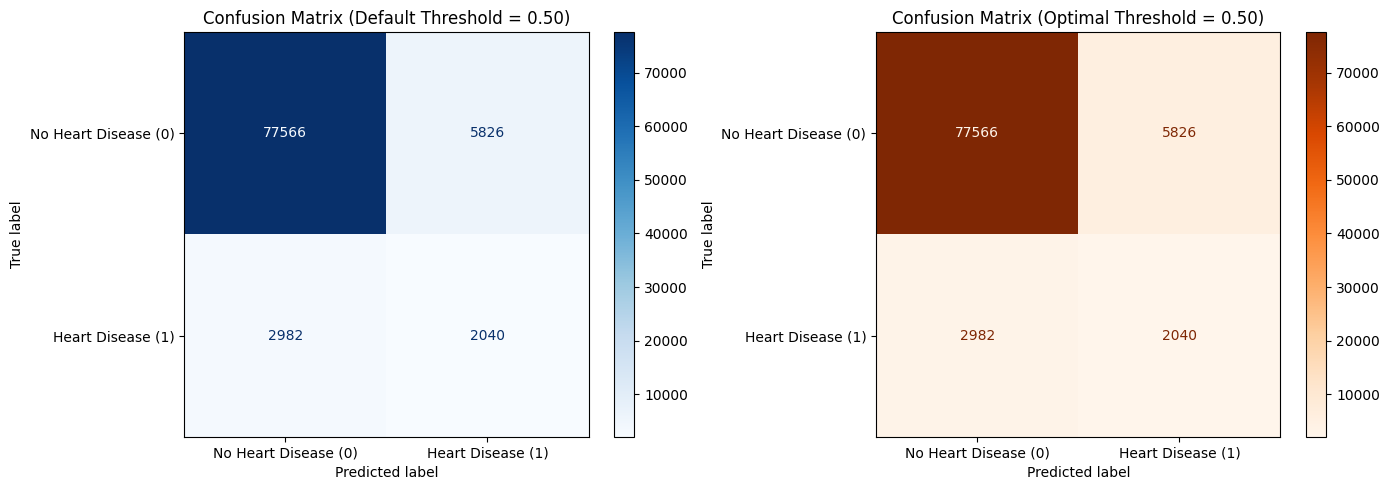

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_default,
    display_labels=target_names,
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Default Threshold = 0.50)")

# Optimal threshold
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_optimal,
    display_labels=target_names,
    cmap="Oranges",
    ax=axes[1],
)
axes[1].set_title(f"Confusion Matrix (Optimal Threshold = {OPTIMAL_THRESHOLD:.2f})")

plt.tight_layout()
plt.show()


### 8.3 ROC-AUC Score & Curve

ROC-AUC measures how well the model ranks positive cases above negative cases across all thresholds.
It is useful for comparing ranking ability independently of a single operating threshold.


ROC-AUC Score: 0.8389


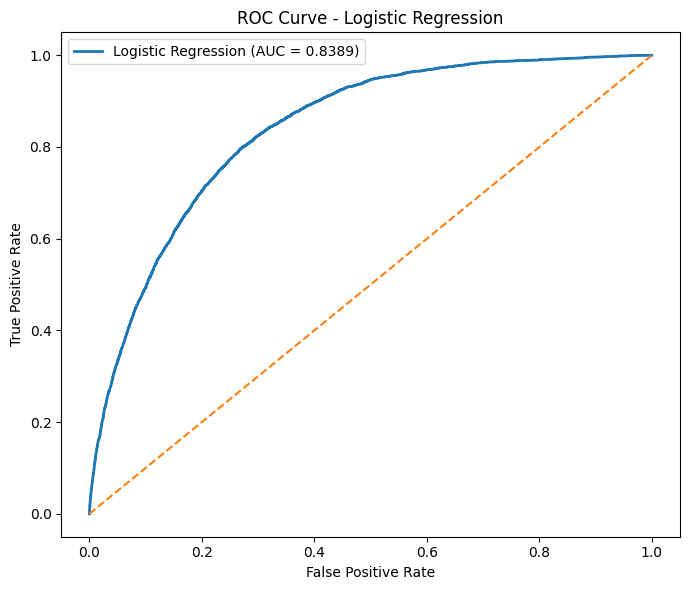

In [14]:
roc_auc = roc_auc_score(y_test_enc, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test_enc, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()


### 8.4 Precision-Recall Curve

Because the positive class is rare, the Precision-Recall curve is especially informative.
It shows how much precision must be sacrificed to gain more recall.


PR-AUC Score: 0.2525


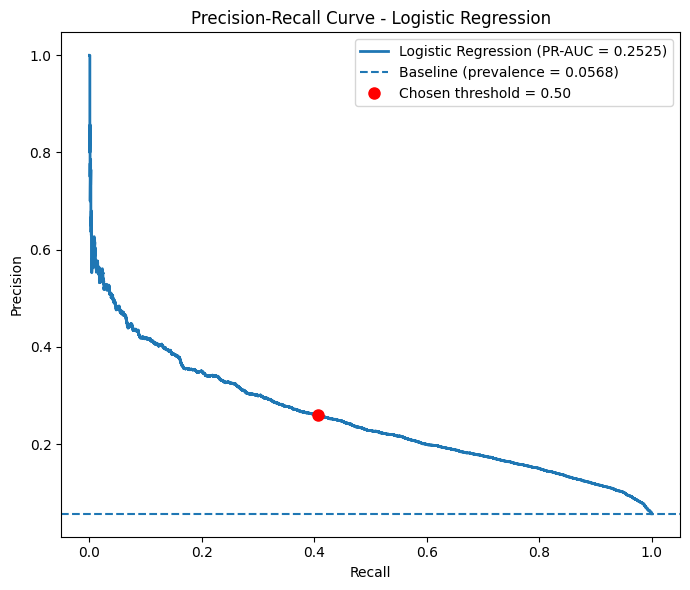

In [15]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test_enc, y_proba)
pr_auc = auc(recalls, precisions)

print(f"PR-AUC Score: {pr_auc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(
    recalls,
    precisions,
    linewidth=2,
    label=f"Logistic Regression (PR-AUC = {pr_auc:.4f})"
)
ax.axhline(
    y=np.mean(y_test_enc),
    linestyle="--",
    label=f"Baseline (prevalence = {np.mean(y_test_enc):.4f})"
)

if len(pr_thresholds) > 0:
    idx_opt = np.argmin(np.abs(pr_thresholds - OPTIMAL_THRESHOLD))
    idx_opt = min(idx_opt, len(recalls) - 1)
    ax.plot(
        recalls[idx_opt],
        precisions[idx_opt],
        "ro",
        markersize=8,
        label=f"Chosen threshold = {OPTIMAL_THRESHOLD:.2f}"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()


### 8.5 Failure Analysis — Top 10 Most Confident Failures

This section extracts the most confident wrong predictions.
These cases are useful for identifying:
- feature patterns the model struggles with,
- potentially ambiguous records,
- cases where the tuned threshold may still be too conservative or too aggressive.


In [16]:
failure_df = pd.DataFrame({
    "actual": y_test_enc,
    "predicted_prob": y_proba,
    "predicted_label": y_pred_optimal
})

# Keep only wrong predictions
errors = failure_df[failure_df["actual"] != failure_df["predicted_label"]].copy()

# Confidence of wrong prediction
errors["confidence"] = np.where(
    errors["predicted_label"] == 1,
    errors["predicted_prob"],
    1 - errors["predicted_prob"]
)

# Label failure type
errors["failure_type"] = np.where(
    (errors["actual"] == 1) & (errors["predicted_label"] == 0),
    "False Negative",
    "False Positive"
)

# Map labels back to text
errors["actual_label"] = errors["actual"].map({0: "No", 1: "Yes"})
errors["predicted_label_text"] = errors["predicted_label"].map({0: "No", 1: "Yes"})

# Most confident wrong predictions
top_10 = errors.sort_values("confidence", ascending=False).head(10)

print("Top 10 Most Confident Wrong Predictions")
print("=" * 80)
print(top_10[[
    "actual_label",
    "predicted_label_text",
    "predicted_prob",
    "confidence",
    "failure_type"
]].to_string(index=True))


Top 10 Most Confident Wrong Predictions
      actual_label predicted_label_text  predicted_prob  confidence    failure_type
47827          Yes                   No        0.005658    0.994342  False Negative
23559          Yes                   No        0.009016    0.990984  False Negative
33708          Yes                   No        0.009454    0.990546  False Negative
48579          Yes                   No        0.009738    0.990262  False Negative
62661          Yes                   No        0.010788    0.989212  False Negative
21827          Yes                   No        0.011119    0.988881  False Negative
12409          Yes                   No        0.011325    0.988675  False Negative
48272          Yes                   No        0.011944    0.988056  False Negative
66324          Yes                   No        0.012899    0.987101  False Negative
27189          Yes                   No        0.013095    0.986905  False Negative


In [17]:
# Examine feature values of the top 10 failures
top_10_indices = top_10.index.tolist()
top_10_features = X_test.iloc[top_10_indices].copy()
top_10_features.insert(0, "actual_label", top_10["actual_label"].values)
top_10_features.insert(1, "predicted_prob", top_10["predicted_prob"].values)
top_10_features.insert(2, "failure_type", top_10["failure_type"].values)

print("Feature values for top 10 most confident failures:")
display(top_10_features.T)


Feature values for top 10 most confident failures:


,47827,23559,33708,48579,62661,21827,12409,48272,66324,27189
actual_label,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
predicted_prob,0.005658,0.009016,0.009454,0.009738,0.010788,0.011119,0.011325,0.011944,0.012899,0.013095
failure_type,False Negative,False Negative,False Negative,False Negative,False Negative,False Negative,False Negative,False Negative,False Negative,False Negative
Sex,0,0,0,0,0,0,0,0,0,1
PhysicalHealthDays,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
"TetanusLast10Tdap_Yes, received tetanus shot but not sure what type",False,False,False,False,False,False,False,False,False,True
"TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",False,False,False,False,False,False,False,False,False,False
CovidPos_No,True,True,True,True,True,True,True,True,True,True
CovidPos_Tested positive using home test without a health professional,False,False,False,False,False,False,False,False,False,False


## 9. Feature Importance

Unlike tree-based models, Logistic Regression does not produce impurity-based feature importance.
However, its coefficients are directly interpretable:
- a **positive coefficient** increases the log-odds of the positive class,
- a **negative coefficient** decreases the log-odds,
- the absolute magnitude indicates relative influence after scaling.

This makes Logistic Regression especially useful for interpretation and model explanation.


In [18]:
# Extract Logistic Regression model from pipeline
logreg_model = best_pipeline.named_steps["logreg"]
coefficients = logreg_model.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
}).sort_values("AbsCoefficient", ascending=False)

print("Top 20 most influential features by absolute coefficient:")
display(coef_df.head(20))


Top 20 most influential features by absolute coefficient:


,Feature,Coefficient,AbsCoefficient
0,Sex,0.398287,0.398287
56,AgeCategory_Age 18 to 24,-0.386326,0.386326
57,AgeCategory_Age 25 to 29,-0.332692,0.332692
58,AgeCategory_Age 30 to 34,-0.315685,0.315685
26,GeneralHealth_Excellent,-0.278109,0.278109
18,ChestScan,0.277300,0.277300
68,AgeCategory_Age 80 or older,0.252849,0.252849
59,AgeCategory_Age 35 to 39,-0.238507,0.238507
5,HadStroke,0.225658,0.225658
60,AgeCategory_Age 40 to 44,-0.217487,0.217487


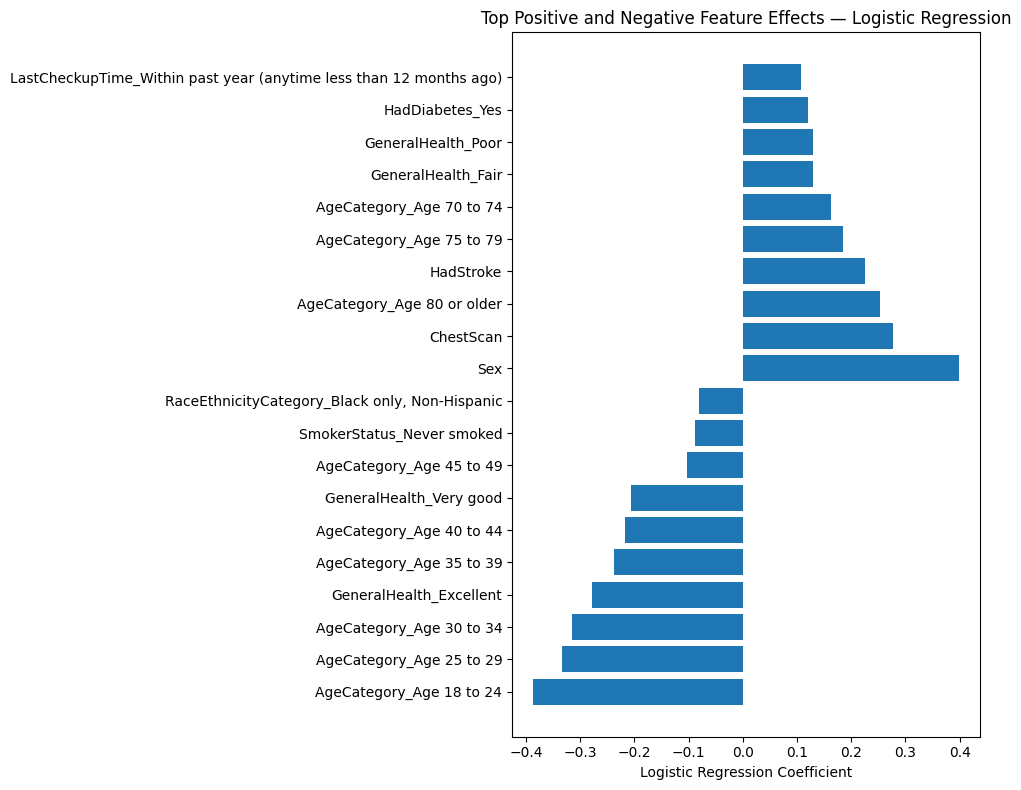

In [19]:
# Plot top positive and negative coefficients
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(10)

plot_df = pd.concat([top_negative, top_positive])

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["Feature"], plot_df["Coefficient"])
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top Positive and Negative Feature Effects — Logistic Regression")
plt.tight_layout()
plt.show()


## 10. Comparison Metrics Summary

This summary consolidates the key metrics for easier comparison against the other Stage 2 candidate models.


In [20]:
# Cross-validation metrics from the search
cv_results = pd.DataFrame(random_search.cv_results_)
best_idx = random_search.best_index_

mean_cv_f1 = cv_results.loc[best_idx, "mean_test_score"]
std_cv_f1 = cv_results.loc[best_idx, "std_test_score"]

# Test set metrics with optimal threshold
test_accuracy = accuracy_score(y_test_enc, y_pred_optimal)
test_f1_macro = f1_score(y_test_enc, y_pred_optimal, average="macro")
test_f1_yes = f1_score(y_test_enc, y_pred_optimal, average="binary")
test_precision_yes = precision_score(y_test_enc, y_pred_optimal, average="binary", zero_division=0)
test_recall_yes = recall_score(y_test_enc, y_pred_optimal, average="binary", zero_division=0)
test_roc_auc = roc_auc_score(y_test_enc, y_proba)

summary = pd.DataFrame({
    "Model": ["Logistic Regression (tuned)"],
    "Best CV F1": [f"{mean_cv_f1:.4f} ± {std_cv_f1:.4f}"],
    "Test Accuracy": [f"{test_accuracy:.4f}"],
    "Test F1 (Macro)": [f"{test_f1_macro:.4f}"],
    "Test F1 (Yes)": [f"{test_f1_yes:.4f}"],
    "Test Precision (Yes)": [f"{test_precision_yes:.4f}"],
    "Test Recall (Yes)": [f"{test_recall_yes:.4f}"],
    "Test ROC-AUC": [f"{test_roc_auc:.4f}"],
    "Chosen Threshold": [f"{OPTIMAL_THRESHOLD:.2f}"]
})

print("Comparison Metrics Summary")
print("=" * 80)
print(summary.to_string(index=False))


Comparison Metrics Summary
                      Model      Best CV F1 Test Accuracy Test F1 (Macro) Test F1 (Yes) Test Precision (Yes) Test Recall (Yes) Test ROC-AUC Chosen Threshold
Logistic Regression (tuned) 0.3250 ± 0.0035        0.9004          0.6314        0.3166               0.2593            0.4062       0.8389             0.50


In [21]:
print("=" * 80)
print("FINAL PIPELINE")
print("=" * 80)
print(best_pipeline)

print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS")
print("=" * 80)
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")


FINAL PIPELINE
Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=np.float64(0.02069138081114789),
                                    class_weight={0: 1, 1: 5}, max_iter=5000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

BEST HYPERPARAMETERS
logreg__solver: liblinear
logreg__penalty: l1
logreg__class_weight: {0: 1, 1: 5}
logreg__C: 0.02069138081114789
